<a href="https://colab.research.google.com/github/w-b-d/Ml-Project/blob/brianna/notebook/training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Breast Cancer Detection**
**Team Members:**  
- Anghel Carrillo  
- Kristopher Church  
- Brianna Magallon  
- William Brady-Diaz  

**Date:** December 2025  


In [33]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, random_split
import glob
from PIL import Image
import zipfile
import io
import os
from PIL import Image
import matplotlib.pyplot as plt

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Extract IDC Breast Cancer Dataset into Colab Runtime

In [22]:
zip_path = "/content/drive/MyDrive/LeBromide/data/IDC_regular_ps50_idx5.zip"
!unzip -q "$zip_path" -d data/
print("Dataset extracted into /content/data/")

Dataset extracted into /content/data/


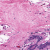

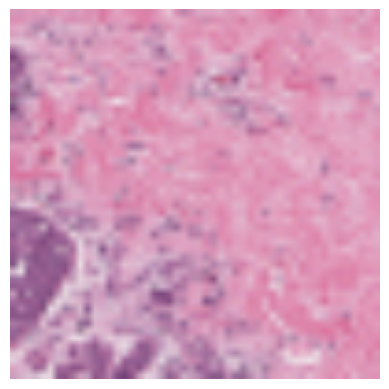

In [36]:
#first image
example_path, _ = dataset[0]
plt.imshow(example_path.permute(1,2,0))
plt.axis("off")

img

## ** Baseline Model **


In [24]:
class IDCDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        self.files = []

        for label in ["0", "1"]:
            pattern = os.path.join(root, "**", label, "*.png")
            for f in glob.glob(pattern, recursive=True):
                self.files.append((f, int(label)))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path, label = self.files[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label


Initialize Dataset and Apply Transforms

In [25]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

dataset = IDCDataset("data/IDC_regular_ps50_idx5", transform)
print("Total images:", len(dataset))

Total images: 277524


Train/Validation Split and DataLoaders

In [26]:
train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size

train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=64)

len(train_loader), len(val_loader)


(3470, 868)

In [31]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = models.resnet18(weights='DEFAULT')

model.fc = nn.Sequential(
    nn.Linear(512, 1),
    nn.Sigmoid()
)

model = model.to(device)
model


Using device: cpu


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  